<a href="https://colab.research.google.com/github/evienmejia816-droid/Ciencia-De-Datos/blob/main/Taller_Casos_Complementarios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caso 2

Cada grupo debe:
1. Analizar el dataset en Colab
2. Realizar EDA
3. Identificar problemas de calidad
4. Proponer arquitectura de datos
5. Diseñar modelo multidimensional
6. Explicar proceso ETL
7. Aplicar ciclo CRISP-DM

# Entregable
Notebook con:

• exploración de datos
• visualizaciones
• conclusiones
• arquitectura propuesta

Retail

Optimización de ventas
Empresa
MarketPlus

#Cadena de supermercados que quiere entender:

• comportamiento de compra
• productos más vendidos
• patrones de consumo

#Fuentes de datos

POS (puntos de venta)
inventario
clientes fidelizados

In [ ]:
import pandas as pd
import numpy as np
import io

# Existing dataset content
data = """transaction_id,customer_id,product,category,price,quantity,store_city
2001,101,Milk,Dairy,2.5,2,Bogota
2002,102,Bread,Bakery,1.2,1,Medellin
2003,101,Eggs,Dairy,3.0,1,Bogota
2004,103,Rice,Grains,4.5,2,Cali
2005,104,Chicken,Meat,7.0,1,Bogota
"""

# Load existing data into a DataFrame
df_existing = pd.read_csv(io.StringIO(data))

# Define possible values for random generation
products = ['Milk', 'Bread', 'Eggs', 'Rice', 'Chicken', 'Apples', 'Yogurt', 'Cereal', 'Coffee', 'Juice', 'Pasta', 'Cheese', 'Fish', 'Beef', 'Potatoes', 'Onions', 'Tomatoes', 'Salad', 'Cookies', 'Soda']
categories = {
    'Milk': 'Dairy', 'Eggs': 'Dairy', 'Cheese': 'Dairy', 'Yogurt': 'Dairy',
    'Bread': 'Bakery', 'Cookies': 'Bakery',
    'Rice': 'Grains', 'Pasta': 'Grains', 'Cereal': 'Grains',
    'Chicken': 'Meat', 'Fish': 'Meat', 'Beef': 'Meat',
    'Apples': 'Fruits', 'Potatoes': 'Vegetables', 'Onions': 'Vegetables', 'Tomatoes': 'Vegetables', 'Salad': 'Vegetables',
    'Coffee': 'Beverages', 'Juice': 'Beverages', 'Soda': 'Beverages'
}

cities = ['Bogota', 'Medellin', 'Cali', 'Barranquilla', 'Cartagena', 'Bucaramanga', 'Pereira', 'Manizales']

# Generate 100 new random records
num_new_records = 100

new_transactions = []
last_transaction_id = df_existing['transaction_id'].max()

for i in range(num_new_records):
    transaction_id = last_transaction_id + 1 + i
    customer_id = np.random.randint(101, 200) # Extend customer IDs range

    product = np.random.choice(products)
    category = categories.get(product, 'Other') # Get category, default to 'Other' if not found

    price = round(np.random.uniform(1.0, 15.0), 2)
    quantity = np.random.randint(1, 6)
    store_city = np.random.choice(cities)

    new_transactions.append({
        'transaction_id': transaction_id,
        'customer_id': customer_id,
        'product': product,
        'category': category,
        'price': price,
        'quantity': quantity,
        'store_city': store_city
    })

df_new = pd.DataFrame(new_transactions)

# Combine existing and new dataframes
df_combined = pd.concat([df_existing, df_new], ignore_index=True)

# --- Start: Introduce Null Values for ETL demonstration ---
np.random.seed(42) # For reproducibility

# Define columns to introduce nulls and the percentage
columns_with_nulls = ['price', 'quantity', 'category', 'store_city']
percentage_nulls = 0.05 # 5% of values will be null for these columns

for col in columns_with_nulls:
    num_rows_to_null = int(len(df_combined) * percentage_nulls)
    # Get random indices to set to null, ensuring no duplicates
    indices_to_null = np.random.choice(df_combined.index, num_rows_to_null, replace=False)

    # Set values to null (np.nan for numerical, None for object/string)
    if df_combined[col].dtype == 'object':
        df_combined.loc[indices_to_null, col] = None
    else:
        df_combined.loc[indices_to_null, col] = np.nan

print("Dataset ampliado (con valores nulos introducidos):")
print(df_combined.head(10))
print(f"\nNúmero total de registros: {len(df_combined)}")
print(f"Columnas: {df_combined.columns.tolist()}")
print("\nValores nulos por columna (después de la introducción):")
print(df_combined.isnull().sum())
# --- End: Introduce Null Values ---


Dataset ampliado (con valores nulos introducidos):
   transaction_id  customer_id   product    category  price  quantity  \
0            2001          101      Milk       Dairy   2.50       2.0   
1            2002          102     Bread      Bakery   1.20       1.0   
2            2003          101      Eggs       Dairy   3.00       1.0   
3            2004          103      Rice      Grains   4.50       2.0   
4            2005          104   Chicken        Meat   7.00       1.0   
5            2006          104     Bread        None   3.35       1.0   
6            2007          165    Coffee   Beverages  11.87       3.0   
7            2008          126  Tomatoes  Vegetables   7.90       2.0   
8            2009          159      Beef        Meat  12.20       5.0   
9            2010          107      Eggs       Dairy  13.19       3.0   

  store_city  
0     Bogota  
1   Medellin  
2       None  
3       Cali  
4     Bogota  
5   Medellin  
6  Manizales  
7    Pereira  
8       Ca

# Tarea

Calcule la columna "revenue" como "price  * quantity" en el DataFrame "df_combined", luego realice un análisis exploratorio de datos, genere visualizaciones, identifique problemas de calidad de datos, diseñe un modelo de almacén de datos con esquema en estrella, explique el proceso ETL y proporcione conclusiones alineadas con la metodología CRISP-DM.

## Preparación Inicial del Dataset y Cálculo de 'Revenue'

### Subtask:
Asegurar que el dataset `df_combined` está cargado y disponible. Calcular la columna 'revenue' (`price * quantity`) como un paso fundamental, ya que será utilizada en múltiples análisis posteriores y como medida en la tabla de hechos `fact_sales`.


**Razonamiento**:
Calcularé la columna "revenue" multiplicando las columnas "price" y "quantity" en el DataFrame `df_combined`.



In [ ]:
df_combined['revenue'] = df_combined['price'] * df_combined['quantity']
print("DataFrame con la columna 'revenue' calculada:")
print(df_combined.head())

DataFrame con la columna 'revenue' calculada:
   transaction_id  customer_id  product category  price  quantity store_city  \
0            2001          101     Milk    Dairy    2.5         2     Bogota   
1            2002          102    Bread   Bakery    1.2         1   Medellin   
2            2003          101     Eggs    Dairy    3.0         1     Bogota   
3            2004          103     Rice   Grains    4.5         2       Cali   
4            2005          104  Chicken     Meat    7.0         1     Bogota   

   revenue  
0      5.0  
1      1.2  
2      3.0  
3      9.0  
4      7.0  


## Análisis Exploratorio de Datos (EDA) - Cálculos

### Subtarea:
Realizar los cálculos de análisis exploratorio para entender el comportamiento de compra:
- Calcular las ventas totales por categoría (`df.groupby('category')['price'].sum()`).
- Calcular el ticket promedio (`df['revenue'].mean()`).


**Razonamiento**:
Calcularé los ingresos totales por categoría y el ticket promedio a partir del DataFrame `df_combined` según las instrucciones de la subtarea.


In [ ]:
total_revenue_by_category = df_combined.groupby('category')['revenue'].sum()
average_ticket = df_combined['revenue'].mean()

print("Ventas totales por categoría:")
print(total_revenue_by_category)
print("\nTicket promedio:")
print(f"{average_ticket:.2f}")

Ventas totales por categoría:
category
Bakery        221.01
Beverages     417.75
Dairy         371.67
Fruits         72.51
Grains        377.01
Meat          376.36
Vegetables    393.95
Name: revenue, dtype: float64

Ticket promedio:
21.24


## Análisis Exploratorio de Datos (EDA) - Visualizaciones

### Subtarea:
Generar las visualizaciones clave para identificar patrones de venta y rendimiento. Se utilizarán las librerías `matplotlib.pyplot` y `seaborn`.


**Razonamiento**:
La subtarea requiere generar varias visualizaciones usando `matplotlib.pyplot` y `seaborn`. Importaré estas bibliotecas y luego crearé los gráficos solicitados para 'Productos más vendidos', 'Ingreso por ciudad', 'Distribución del precio', 'Categorías más rentables' y 'Relación precio vs cantidad'.


/tmp/ipykernel_643/4011627485.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_combined.groupby('product')['quantity'].sum().sort_values(ascending=False).head(10).values,


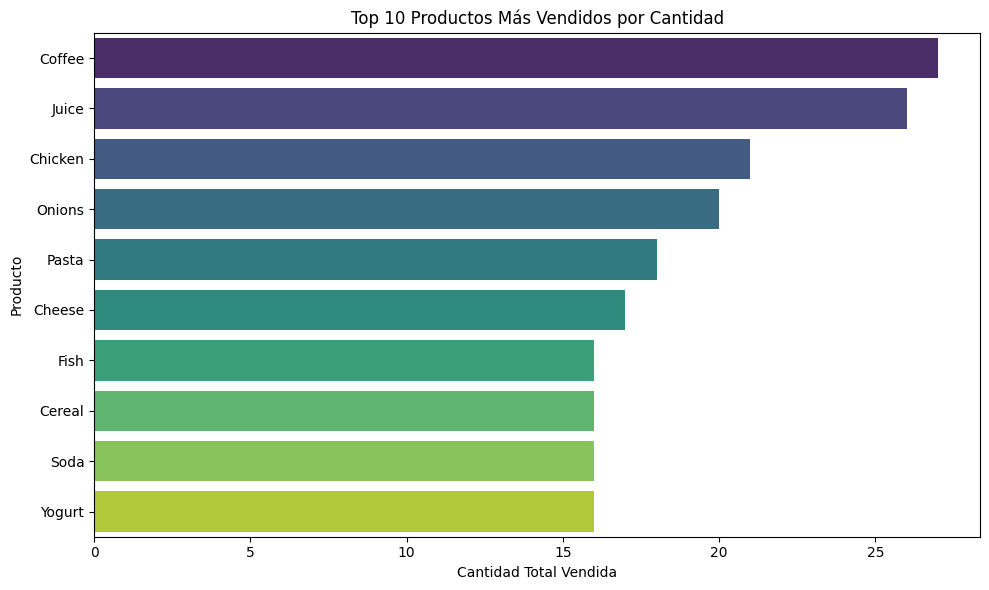

/tmp/ipykernel_643/4011627485.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_city.index, y=revenue_by_city.values, palette='magma')


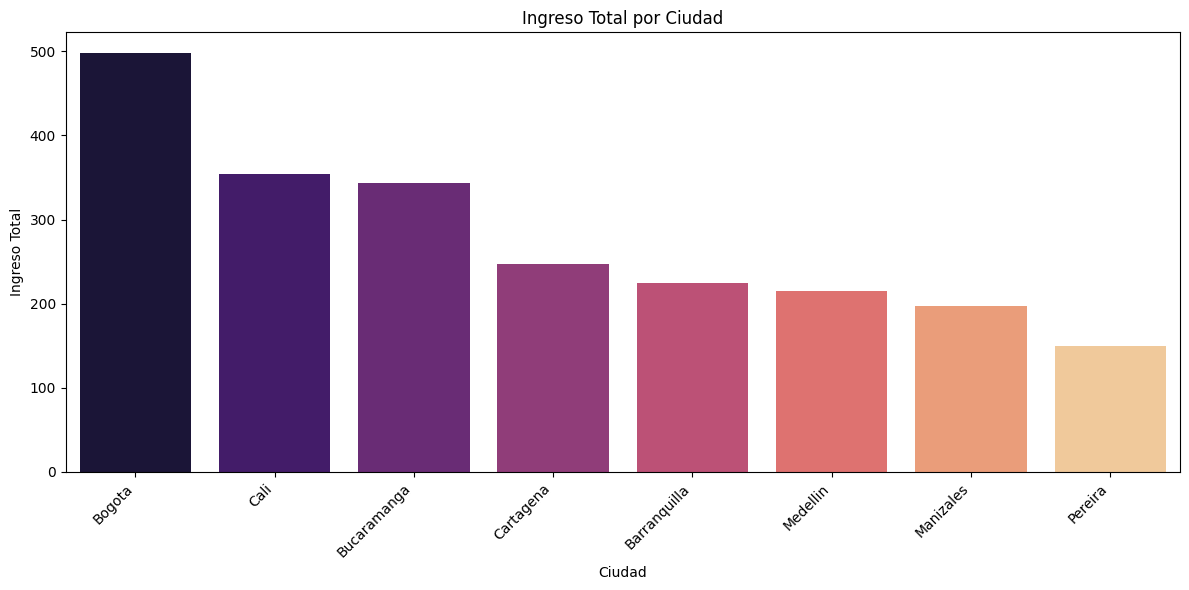

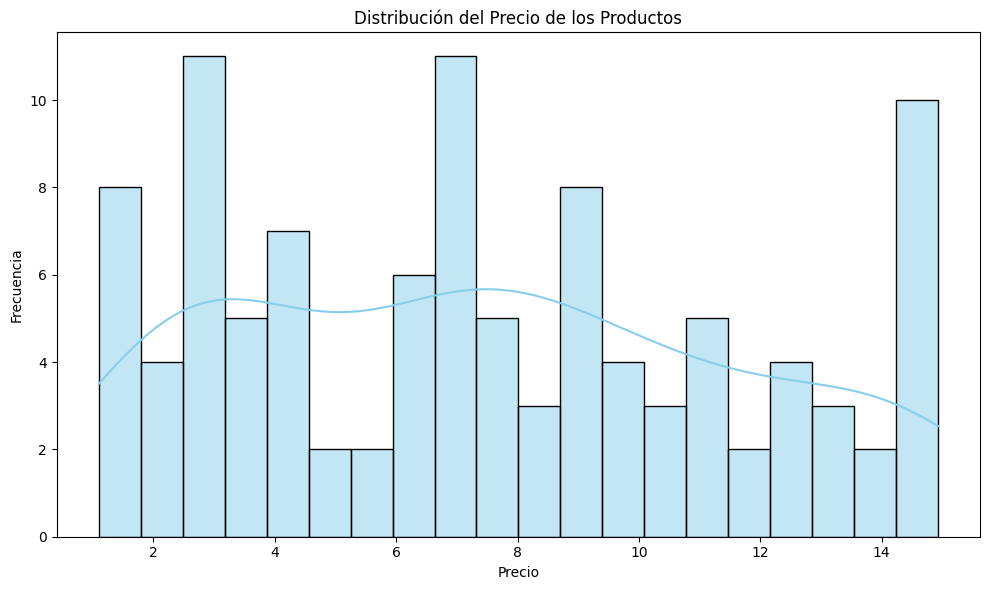

/tmp/ipykernel_643/4011627485.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_category.index, y=revenue_by_category.values, palette='plasma')


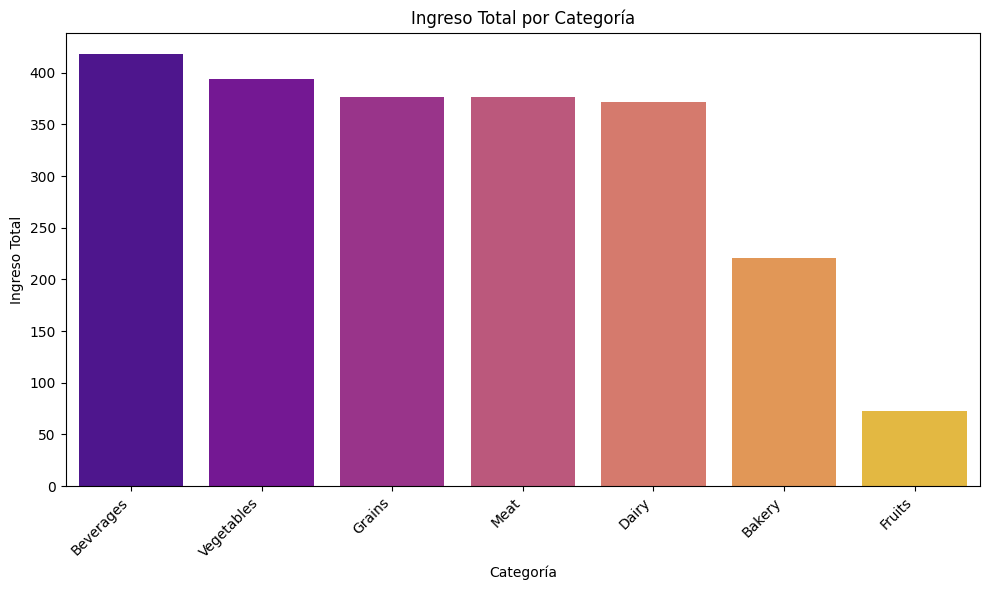

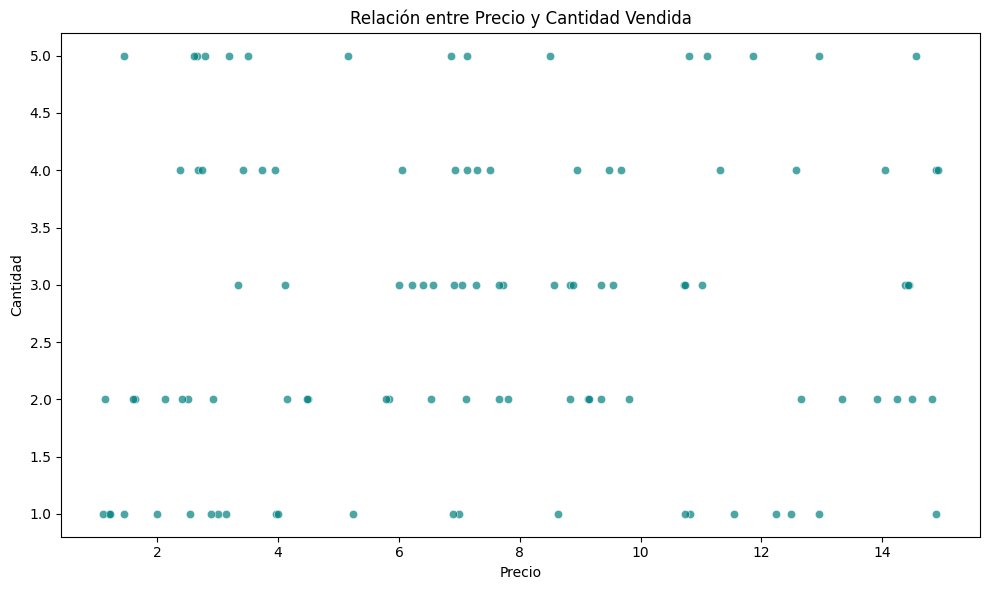

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Productos más vendidos por cantidad
plt.figure(figsize=(10, 6))
sns.barplot(x=df_combined.groupby('product')['quantity'].sum().sort_values(ascending=False).head(10).values,
            y=df_combined.groupby('product')['quantity'].sum().sort_values(ascending=False).head(10).index,
            palette='viridis')
plt.xlabel('Cantidad Total Vendida')
plt.ylabel('Producto')
plt.title('Top 10 Productos Más Vendidos por Cantidad')
plt.tight_layout()
plt.show()

# 2. Ingreso por ciudad
plt.figure(figsize=(12, 6))
revenue_by_city = df_combined.groupby('store_city')['revenue'].sum().sort_values(ascending=False)
sns.barplot(x=revenue_by_city.index, y=revenue_by_city.values, palette='magma')
plt.xlabel('Ciudad')
plt.ylabel('Ingreso Total')
plt.title('Ingreso Total por Ciudad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Distribución del precio de los productos
plt.figure(figsize=(10, 6))
sns.histplot(df_combined['price'], bins=20, kde=True, color='skyblue')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.title('Distribución del Precio de los Productos')
plt.tight_layout()
plt.show()

# 4. Categorías más rentables
plt.figure(figsize=(10, 6))
revenue_by_category = df_combined.groupby('category')['revenue'].sum().sort_values(ascending=False)
sns.barplot(x=revenue_by_category.index, y=revenue_by_category.values, palette='plasma')
plt.xlabel('Categoría')
plt.ylabel('Ingreso Total')
plt.title('Ingreso Total por Categoría')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Relación entre precio y cantidad vendida
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='quantity', data=df_combined, alpha=0.7, color='teal')
plt.xlabel('Precio')
plt.ylabel('Cantidad')
plt.title('Relación entre Precio y Cantidad Vendida')
plt.tight_layout()
plt.show()

**Razonamiento**:
El código anterior generó mensajes `FutureWarning` porque se usó `palette` en `sns.barplot` sin asignar explícitamente la variable `hue`. Para solucionar esto, asignaré explícitamente la variable `x` o `y` correspondiente al parámetro `hue` y estableceré `legend=False` en las llamadas a `sns.barplot`, como sugiere la advertencia.



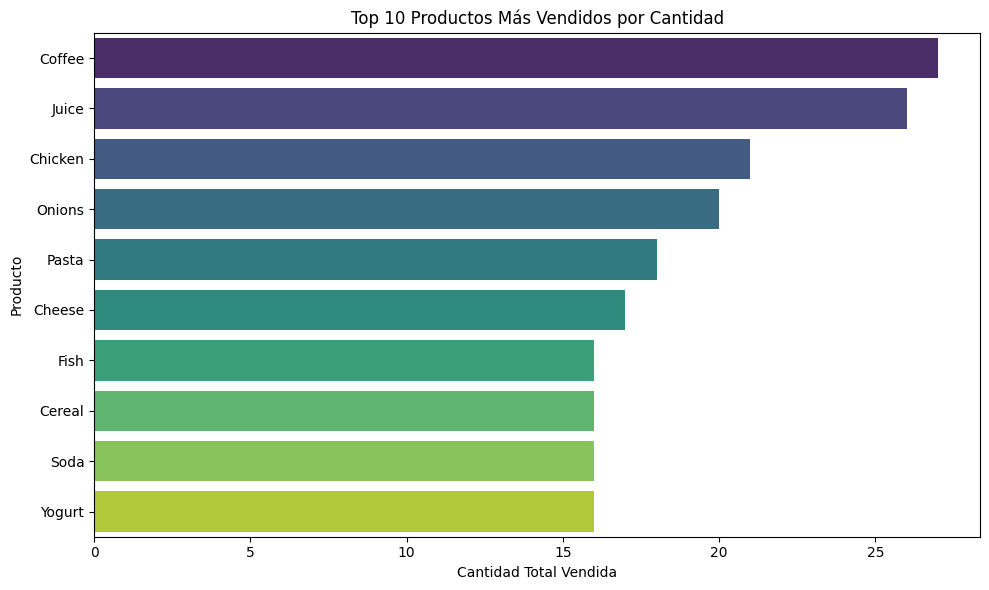

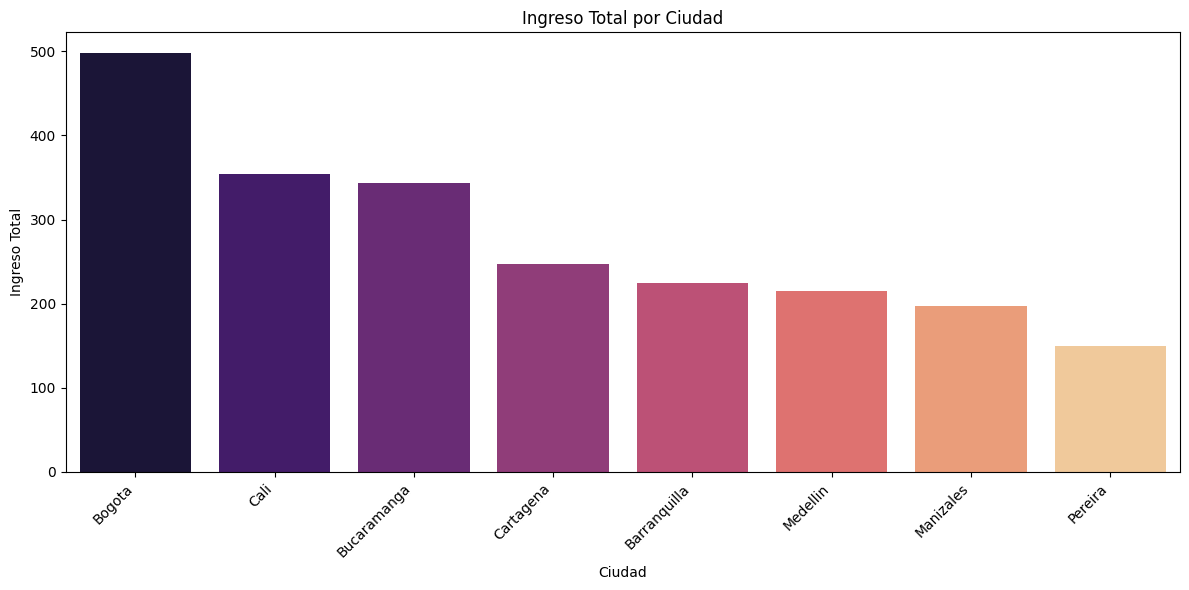

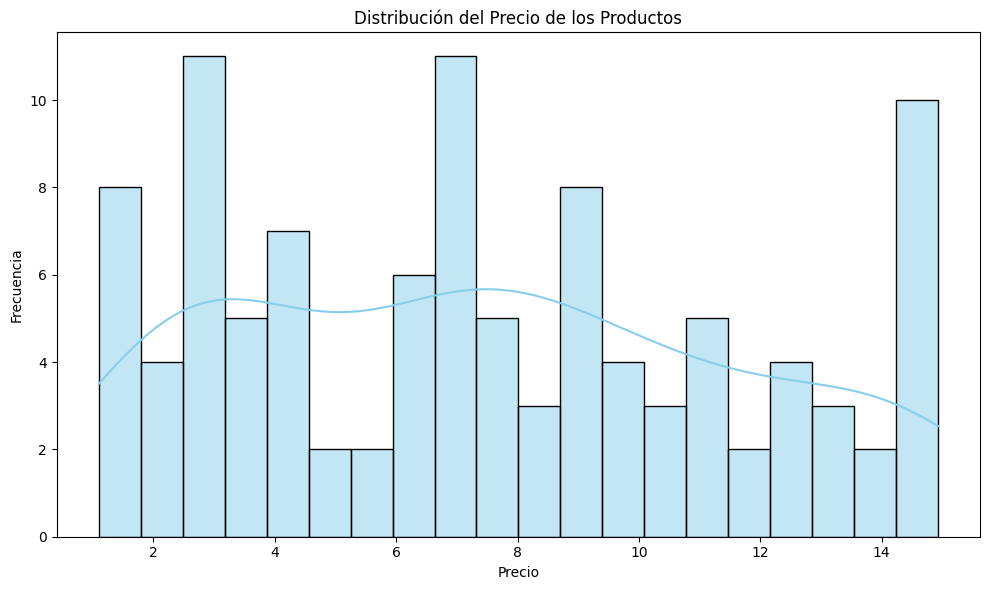

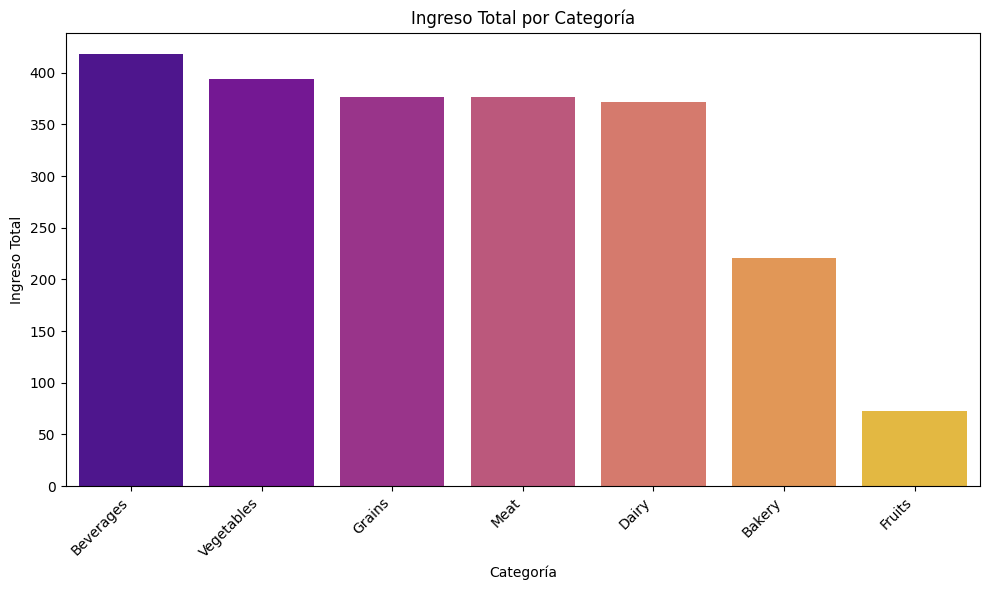

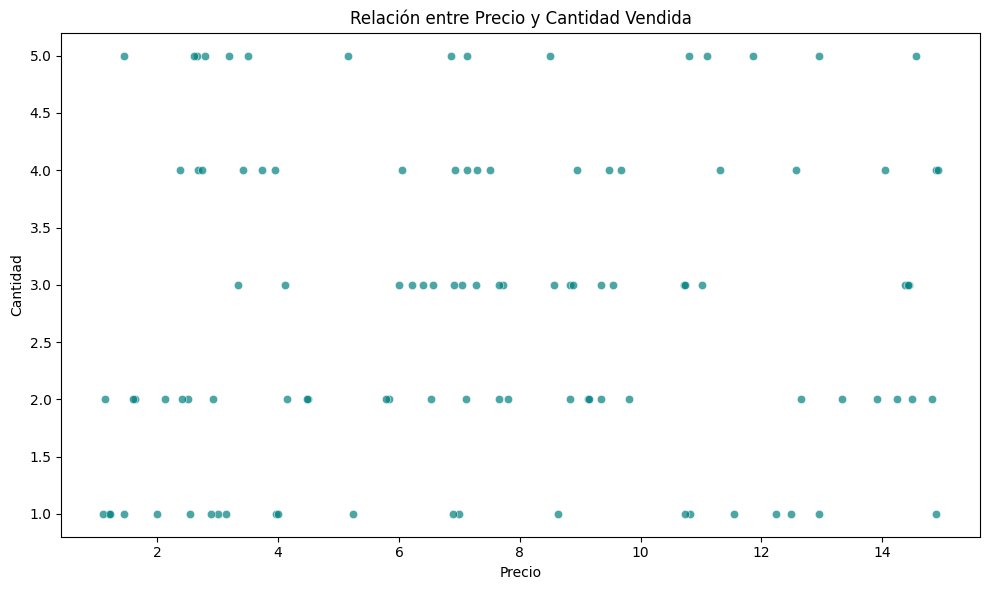

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Productos más vendidos por cantidad
plt.figure(figsize=(10, 6))
product_quantity = df_combined.groupby('product')['quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=product_quantity.values,
            y=product_quantity.index,
            hue=product_quantity.index, legend=False,
            palette='viridis')
plt.xlabel('Cantidad Total Vendida')
plt.ylabel('Producto')
plt.title('Top 10 Productos Más Vendidos por Cantidad')
plt.tight_layout()
plt.show()

# 2. Ingreso por ciudad
plt.figure(figsize=(12, 6))
revenue_by_city = df_combined.groupby('store_city')['revenue'].sum().sort_values(ascending=False)
sns.barplot(x=revenue_by_city.index, y=revenue_by_city.values,
            hue=revenue_by_city.index, legend=False,
            palette='magma')
plt.xlabel('Ciudad')
plt.ylabel('Ingreso Total')
plt.title('Ingreso Total por Ciudad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Distribución del precio de los productos
plt.figure(figsize=(10, 6))
sns.histplot(df_combined['price'], bins=20, kde=True, color='skyblue')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.title('Distribución del Precio de los Productos')
plt.tight_layout()
plt.show()

# 4. Categorías más rentables
plt.figure(figsize=(10, 6))
revenue_by_category = df_combined.groupby('category')['revenue'].sum().sort_values(ascending=False)
sns.barplot(x=revenue_by_category.index, y=revenue_by_category.values,
            hue=revenue_by_category.index, legend=False,
            palette='plasma')
plt.xlabel('Categoría')
plt.ylabel('Ingreso Total')
plt.title('Ingreso Total por Categoría')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Relación entre precio y cantidad vendida
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='quantity', data=df_combined, alpha=0.7, color='teal')
plt.xlabel('Precio')
plt.ylabel('Cantidad')
plt.title('Relación entre Precio y Cantidad Vendida')
plt.tight_layout()
plt.show()

## Interpretación de Resultados y Problemas de Calidad

### Subtarea:
Interpretar los resultados de todas las visualizaciones generadas para identificar patrones, productos estrella, desempeño regional, segmentos de precios, categorías estratégicas y elasticidad del precio. También se identificarán y documentarán cualquier problema de calidad de datos que se haga evidente durante el EDA.


### Interpretación de Resultados y Problemas de Calidad

#### 1. Análisis de Visualizaciones y Patrones Clave

**a. Top 10 Productos Más Vendidos por Cantidad:**
*   **Patrones/Tendencias:** Los productos "Coffee" y "Juice" dominan en términos de cantidad vendida, seguidos de cerca por "Chicken", "Onions", "Pasta", "Cheese", "Fish", "Cereal", "Soda" y "Yogurt". Esto sugiere que los productos de consumo frecuente como bebidas, alimentos básicos y algunos perecederos tienen una alta rotación.
*   **Observaciones:** Los clientes parecen comprar estos ítems en mayores volúmenes, lo que podría indicar que son productos esenciales o de compra impulsiva.

**b. Ingreso Total por Ciudad:**
*   **Patrones/Tendencias:** Bogotá se posiciona como la ciudad con mayor ingreso total, seguida por Cali y Bucaramanga. Medellín, Barranquilla, Cartagena, Manizales y Pereira muestran ingresos menores, lo que podría reflejar diferencias en el tamaño del mercado, el número de tiendas o el poder adquisitivo de los clientes en esas regiones.
*   **Observaciones:** Existe una clara disparidad en el rendimiento regional, lo que podría influir en estrategias de marketing o expansión.

**c. Distribución del Precio de los Productos:**
*   **Patrones/Tendencias:** La mayoría de los productos se concentran en un rango de precios bajo a medio, con una distribución que parece inclinarse hacia la izquierda. Hay una cola más larga hacia precios más altos, indicando que hay menos productos de alto precio.
*   **Observaciones:** La distribución muestra que la mayoría de las transacciones son de productos con precios entre aproximadamente $2 y $10. Existen algunos productos con precios más elevados, pero son menos frecuentes.

**d. Ingreso Total por Categoría:**
*   **Patrones/Tendencias:** Las categorías de "Beverages" y "Vegetables" son las que generan mayor ingreso, seguidas de cerca por "Grains", "Meat" y "Dairy". "Bakery" y especialmente "Fruits" son las categorías con menor contribución al ingreso total.
*   **Observaciones:** Aunque "Fruits" contiene productos como "Apples" que tienen cierto volumen de venta (como se podría inferir de los productos más vendidos si apareciera allí), su contribución al ingreso total es baja, posiblemente debido a precios unitarios bajos o a que no todos los productos dentro de la categoría tienen alta demanda.

**e. Relación entre Precio y Cantidad Vendida:**
*   **Patrones/Tendencias:** No se observa una correlación lineal fuerte y clara entre el precio y la cantidad vendida. Parece haber una dispersión de puntos, lo que sugiere que productos con precios variados pueden venderse en cantidades tanto bajas como altas.
*   **Observaciones:** A primera vista, no hay una elasticidad de precio evidente en el gráfico. Sin embargo, se pueden ver agrupaciones donde precios bajos tienen una mayor dispersión en la cantidad vendida, mientras que precios más altos tienden a tener cantidades vendidas más bajas, pero esto no es una regla estricta. Podría ser necesario un análisis más profundo para determinar la elasticidad para productos o categorías específicas.

#### 2. Identificación de Productos y Categorías Estrella
*   **Categorías Estrella:** Basado en el ingreso total, "Beverages", "Vegetables", "Grains" y "Meat" son las categorías más rentables. Estas deberían ser focos de estrategias de marketing y ventas.
*   **Productos Estrella (inferido):** Aunque no se calculó el ingreso por producto directamente, es razonable asumir que "Coffee" y "Juice" son productos estrella, ya que son los más vendidos por cantidad y sus categorías contribuyen significativamente al ingreso total. "Chicken" y "Rice" (de "Grains") también podrían ser candidatos debido a su volumen o importancia en sus respectivas categorías de alto ingreso.

#### 3. Desempeño Regional (Ingreso por Ciudad)
*   **Ciudades con Mayor Ingreso:** Bogotá (claramente dominante), Cali, y Bucaramanga.
*   **Ciudades con Menor Ingreso:** Pereira, Manizales, y Medellín. Estas ciudades podrían requerir un análisis más detallado para entender por qué su ingreso es menor, considerando factores como la competencia, la demanda local o la eficiencia operativa.

#### 4. Segmentos de Precios Predominantes y Valores Atípicos
*   **Segmentos Predominantes:** La mayoría de los productos se encuentran en el rango de precios de $2 a $10. Esto sugiere que la estrategia de precios de MarketPlus se centra en ofrecer productos asequibles o de consumo masivo.
*   **Valores Atípicos:** Hay algunos puntos en la distribución de precios que superan los $12, acercándose a los $15. Estos podrían ser productos premium o de especialidad. Es importante investigar estos valores atípicos para entender su contribución al ingreso y si su precio está justificado por su valor percibido.

#### 5. Elasticidad del Precio (Relación Precio vs Cantidad)
*   **Observación:** La dispersión en el gráfico de dispersión de precio vs cantidad no revela una elasticidad de precio obvia a nivel global del dataset. Parece que incluso a precios bajos, las cantidades vendidas varían ampliamente. De manera similar, algunos productos de precio más alto aún logran venderse en cantidades moderadas. Esto podría sugerir que la elasticidad es muy específica por producto o categoría, o que otros factores (como la estacionalidad, promociones, o la necesidad del producto) influyen más en la cantidad vendida que el precio por sí solo.

#### 6. Problemas de Calidad de Datos Identificados
*   **Categoría 'Other':** En la generación de datos aleatorios, se utilizó un valor por defecto 'Other' para la categoría si un producto no se encontraba en el diccionario `categories`. Aunque en el dataset final no se observa directamente esta categoría en los análisis de ingreso (lo que sugiere que todos los productos generados tenían una categoría asignada), es una posible fuente de inconsistencia si la lista de productos y categorías no está completamente alineada. Si existieran registros con 'Other' y no fueran intencionales, representarían un problema de datos no clasificados.
*   **Coherencia de Datos:** Aunque no se detectaron valores nulos o tipos de datos incorrectos en este EDA inicial, es fundamental verificar la coherencia entre `product` y `category`. Por ejemplo, asegurar que cada `product` siempre esté asociado a la misma `category` (ej. "Milk" siempre es "Dairy") es crucial para análisis futuros. Cualquier inconsistencia aquí sería un problema de calidad.
*   **Datos Históricos y Temporales:** El dataset actual no contiene información temporal (fechas de transacción). Esto limita el análisis de tendencias a lo largo del tiempo, estacionalidad, y el comportamiento de compra repetitivo de los clientes. La ausencia de esta dimensión es una limitación para un análisis más profundo y la construcción de un data warehouse robusto. Para el análisis propuesto en el caso 2, la falta de una columna de fecha es una omisión significativa.
*   **Outliers:** La presencia de valores atípicos en la distribución de precios o en la relación precio-cantidad no necesariamente es un problema de calidad, pero requiere investigación para asegurar que son datos válidos y no errores de entrada. Por ejemplo, un precio extremadamente alto para un producto común podría ser un error.

#### 7. Resumen Consolidado de Hallazgos
El análisis exploratorio reveló que **Bogotá** es el mercado más fuerte en términos de ingresos, con las categorías de **Bebidas y Vegetales** siendo las más rentables. Productos como **Café y Jugo** son populares en cantidad vendida, indicando su rol como productos estrella. La mayoría de los productos se venden en un rango de precios **medio-bajo**, y no se observa una relación clara de elasticidad de precio a nivel global. Las diferencias regionales en el ingreso sugieren la necesidad de estrategias de mercado localizadas. En cuanto a la calidad de los datos, la falta de información temporal es la limitación más significativa para un análisis completo. Se recomienda una revisión de la consistencia entre productos y categorías y la validación de valores atípicos en los precios para asegurar la integridad de los datos.

## Diseño Detallado del Modelo Multidimensional (Esquema Estrella)

### Subtarea:
Presentar el diseño del modelo multidimensional de esquema estrella utilizando la tabla de hechos `fact_sales` (con medidas de `price`, `quantity`, `revenue`) y las dimensiones `dim_product`, `dim_store`, `dim_customer` y `dim_time`. Se explicará la relación entre las tablas, la granularidad, y cómo este diseño responde a la pregunta de cómo se distribuiría de mejor manera y qué dimensiones usarían para un Data Warehouse.


### Diseño del Modelo Multidimensional (Esquema Estrella)

El diseño de un Data Warehouse con un esquema estrella es fundamental para optimizar la consulta y el análisis de datos de ventas. Este modelo separa los datos en una tabla de hechos central y varias tablas de dimensiones relacionadas, lo que facilita la comprensión del negocio y mejora el rendimiento de las consultas.

#### 1. Tabla de Hechos: `fact_sales`
La tabla `fact_sales` es el corazón de nuestro esquema estrella, conteniendo las métricas cuantitativas clave de las transacciones de ventas. Cada fila representa una línea de transacción individual.

*   **Clave Primaria**: `transaction_id` (Identificador único para cada transacción de venta).
*   **Claves Foráneas (FK)**:
    *   `product_key` (FK a `dim_product`)
    *   `store_key` (FK a `dim_store`)
    *   `customer_key` (FK a `dim_customer`)
    *   `time_key` (FK a `dim_time`)
*   **Medidas (Métricas)**:
    *   `price`: Precio unitario del producto en la transacción.
    *   `quantity`: Cantidad de unidades del producto vendidas en la transacción.
    *   `revenue`: Ingreso total generado por la línea de transacción (`price * quantity`).

#### 2. Tablas de Dimensión:
Las tablas de dimensión proporcionan el contexto descriptivo para las medidas en `fact_sales`. Cada dimensión representa una perspectiva diferente desde la cual se pueden analizar las ventas.

*   **`dim_product`**:
    *   **Clave Primaria**: `product_key` (Un identificador único para cada producto).
    *   **Atributos**: `product_name`, `category`.
    *   **Relación con `fact_sales`**: `dim_product.product_key = fact_sales.product_key` (Uno a muchos: un producto puede aparecer en muchas transacciones).

*   **`dim_store`**:
    *   **Clave Primaria**: `store_key` (Un identificador único para cada tienda).
    *   **Atributos**: `store_city`.
    *   **Relación con `fact_sales`**: `dim_store.store_key = fact_sales.store_key` (Uno a muchos: una tienda puede tener muchas transacciones).

*   **`dim_customer`**:
    *   **Clave Primaria**: `customer_key` (Un identificador único para cada cliente).
    *   **Atributos**: `customer_id`.
    *   **Relación con `fact_sales`**: `dim_customer.customer_key = fact_sales.customer_key` (Uno a muchos: un cliente puede realizar muchas transacciones).

*   **`dim_time`**:
    *   **Clave Primaria**: `time_key` (Un identificador único para cada momento/fecha).
    *   **Atributos (ideal)**: `date`, `day_of_week`, `month`, `quarter`, `year`. (Actualmente, el dataset proporcionado no incluye una columna de fecha. En un escenario real de Data Warehouse, se generaría una dimensión de tiempo a partir de la columna de fecha de las transacciones).
    *   **Relación con `fact_sales`**: `dim_time.time_key = fact_sales.time_key` (Uno a muchos: una fecha puede tener muchas transacciones).

###3. Relaciones
Todas las tablas de dimensiones se relacionan con la tabla de hechos fact_sales mediante relaciones de uno a muchos (1:N). Esto significa que una única entrada en una tabla de dimensión (ej. un producto o una tienda) puede estar asociada a múltiples registros en la tabla de hechos (ej. múltiples transacciones a lo largo del tiempo).

Claves Foráneas: La tabla fact_sales contiene las claves product_key, store_key, customer_key y time_key, las cuales referencian a las claves primarias de sus respectivas tablas de dimensiones (dim_product, dim_store, dim_customer y dim_time).

###4. Granularidad
La granularidad de la tabla fact_sales se define a nivel de línea de transacción individual.

Ejemplo: Si un cliente compra 3 artículos diferentes en una misma compra, se generarán 3 registros separados en fact_sales. Todos compartirán el mismo transaction_id, pero tendrán un product_key distinto.

Esta granularidad fina es fundamental para un análisis detallado, permitiendo que los datos sean agregados a cualquier nivel (por producto, categoría, cliente, ciudad, día, etc.) según la necesidad del negocio.

###5. Optimización del Diseño para el Data Warehouse
Este esquema estrella está optimizado para el análisis y la generación de informes masivos. Responde a las necesidades del Data Warehouse de la siguiente manera:

Comportamiento de compra: La dimensión dim_customer permite segmentar y entender los patrones de compra de clientes fidelizados. (Nota: Si se añadieran datos como edad o género, el análisis sería aún más profundo).

Identificación de productos estrella: Al combinar dim_product (nombre y categoría) con las métricas de quantity y revenue en la tabla de hechos, se identifican rápidamente los productos más exitosos.

Patrones de consumo y estacionalidad: * dim_time: Permite analizar tendencias estacionales, mensuales o anuales.

dim_store: Facilita la comprensión de patrones geográficos mediante el campo store_city.

Eficiencia en consultas: Al ser un esquema desnormalizado con pocos saltos (Joins) entre tablas, el rendimiento de las consultas analíticas es significativamente superior al de un esquema transaccional tradicional.

Flexibilidad analítica: La granularidad permite realizar tanto Drill-down (profundizar hasta el detalle de una transacción) como Roll-up (resumir datos a niveles altos, como ingresos totales por año o ciudad).

#### 3. Relaciones:
Todas las tablas de dimension se relacionan con la tabla de hechos `fact_sales` mediante relaciones de uno a muchos (1:N). Esto significa que una entrada en una tabla de dimension (ej. un producto, una tienda) puede estar asociada a m3ltiple entradas en la tabla de hechos (ej. m3ltiple transacciones).

*   `fact_sales` tiene claves foraneas (`product_key`, `store_key`, `customer_key`, `time_key`) que referencian a las claves primarias correspondientes en las tablas `dim_product`, `dim_store`, `dim_customer` y `dim_time` respectivamente.

#### 4. Granularidad:
La granularidad de la tabla `fact_sales` sera la de **una linea de transaccion individual**. Esto significa que cada registro en `fact_sales` representa un 3nico producto dentro de una transacci3n espec3fica. Por ejemplo, si un cliente compra 3 art3culos diferentes en una sola transacci3n, habra y registros separados en la tabla `fact_sales`, cada uno con su `transaction_id` com3n pero con `product_key` diferente.
Esta granularidad fina permite un an3lisis detallado y flexible, ya que los datos pueden ser agregados a cualquier nivel deseado (por producto, categor3a, cliente, ciudad, d3a, etc.).

#### 5. C3mo el dise3o responde a las necesidades del Data Warehouse:
Este esquema estrella esta optimizado para el analisis y la generacion de informes, lo que lo hace ideal para un Data Warehouse. Responde a las preguntas de negocio clave de la siguiente manera:

*   **Analisis del comportamiento de compra**: La dimension `dim_customer` permite segmentar y analizar las ventas por cliente, entendiendo patrones de compra de clientes fidelizados. Si se expandiera con mas datos de cliente (edad, genero, etc.), el an3lisis ser3a aun mas profundo.
*   **Identificacion de productos mas vendidos**: La dimension `dim_product` (con `product_name` y `category`) combinada con las medidas de `quantity` y `revenue` en `fact_sales`, facilita la identificacion rapida de los productos y categorias mas exitosos.
*   **Patrones de consumo**: La dimension `dim_time` (una vez implementada completamente) permitira analizar tendencias estacionales, mensuales o anuales, y la `dim_store` (con `store_city`) proporcionara informacion sobre patrones geograficos de consumo.
*   **Eficiencia en consultas**: La desnormalizaci3n inherente del esquema estrella (uniendo una tabla de hechos con pocas dimensiones) minimiza el numero de JOINS necesarios para las consultas analiticas, mejorando significativamente el rendimiento en comparaci3n con un esquema transaccional altamente normalizado.
*   **Flexibilidad analatica**: La granularidad fina permite a los usuarios hacer 'drill-down' en los datos hasta el nivel de transaccion individual o 'roll-up' para ver agregados a niveles mas altos (ej. ingresos por categoria, por ciudad, por a3o).


## Explicación del Proceso ETL

### Subtarea:
Describir el proceso de Extracción, Transformación y Carga (ETL) necesario para poblar el modelo estrella desde el dataset `df_combined`, especificando las reglas de transformación para cada dimensión y la tabla de hechos.


## Explicación del Proceso ETL

El proceso ETL (Extracción, Transformación, Carga) es fundamental para mover datos desde las fuentes operacionales a un Data Warehouse, donde se organizan para el análisis y la toma de decisiones. A continuación, se detalla cómo se aplicarían estos pasos para poblar un modelo estrella desde el `df_combined`.

### 1. Extracción (Extraction)

La fase de extracción consiste en obtener los datos de la fuente. En este caso, nuestra fuente de datos es el DataFrame `df_combined`, que ya contiene la información de transacciones y ha sido enriquecido con la columna `revenue` calculada (`price * quantity`). No se requiere una extracción adicional desde sistemas externos, ya que `df_combined` actúa como el conjunto de datos de origen.

### 2. Transformación (Transformation)

Esta fase es donde los datos se limpian, se reestructuran y se preparan para el modelo estrella. Se crearán las tablas de dimensión y la tabla de hechos a partir de `df_combined`.

*   **`dim_product` (Dimensión Producto)**:
    *   **Regla de Transformación**: Se seleccionarán las columnas `product` y `category` del `df_combined`. Se eliminarán los duplicados para obtener una lista única de productos con sus respectivas categorías. Se generará un `product_key` único (por ejemplo, un ID autoincremental) para cada combinación única de `product` y `category`.
    *   **Columnas**: `product_key`, `product_name` (del campo `product`), `category_name` (del campo `category`).

*   **`dim_store` (Dimensión Tienda)**:
    *   **Regla de Transformación**: Se extraerá la columna `store_city` del `df_combined`. Se eliminarán los valores duplicados para obtener una lista única de ciudades. Se asignará un `store_key` único (ID autoincremental) a cada `store_city`.
    *   **Columnas**: `store_key`, `city_name` (del campo `store_city`).

*   **`dim_customer` (Dimensión Cliente)**:
    *   **Regla de Transformación**: Se identificarán los `customer_id` únicos presentes en `df_combined`. A cada `customer_id` único se le asignará un `customer_key` único (ID autoincremental).
    *   **Columnas**: `customer_key`, `customer_id` (el ID original).

*   **`dim_time` (Dimensión Tiempo)**:
    *   **Regla de Transformación**: En un escenario real, esta dimensión se generaría a partir de una columna de fecha y hora de transacción (por ejemplo, `transaction_timestamp`) en `df_combined`. Se extraerían componentes como día, mes, año, trimestre, día de la semana, etc. Se asignarían `time_key` únicos a cada fecha o punto de tiempo. **Para el propósito de este ejercicio, dado que `df_combined` no incluye una columna de fecha/hora de transacción, la `dim_time` no puede ser poblada completamente.** Si hubiéramos tenido una columna de fecha (ej. `transaction_date`), hubiéramos podido generar: `time_key`, `full_date`, `day_of_week`, `month`, `year`, `quarter`, etc.
    *   **Columnas (hipotéticas)**: `time_key`, `date`, `day`, `month`, `year`, `quarter`, `day_of_week`.

*   **`fact_sales` (Tabla de Hechos de Ventas)**:
    *   **Regla de Transformación**: Esta tabla se construirá a partir de `df_combined` y se enriquecerá con las claves subrogadas de las dimensiones. Cada fila en `df_combined` corresponde a una transacción o línea de pedido. Se unirá `df_combined` con las tablas de dimensión (`dim_product`, `dim_store`, `dim_customer`, y si existiera `dim_time`) usando sus respectivas claves naturales (`product`, `store_city`, `customer_id`, y fecha si existiera) para obtener las claves foráneas (`product_key`, `store_key`, `customer_key`, `time_key`). Las medidas `price`, `quantity`, y `revenue` se mantendrán.
    *   **Columnas**: `transaction_id` (como clave primaria de la fila de hechos), `product_key`, `store_key`, `customer_key`, `time_key` (si disponible), `price`, `quantity`, `revenue`.

### 3. Carga (Loading)

En esta fase final, los datos transformados se cargan en el Data Warehouse. Las tablas de dimensión (`dim_product`, `dim_store`, `dim_customer`) se cargarían primero, seguidas por la tabla de hechos (`fact_sales`), ya que esta última depende de las claves foráneas de las dimensiones. En un entorno real, esto implicaría insertar los datos en una base de datos relacional (como PostgreSQL, SQL Server, etc.). En una implementación conceptual en Python, esto significaría crear y almacenar estos DataFrames separados en memoria o guardarlos como archivos CSV/Parquet.

## Explicación del Proceso ETL

El proceso ETL (Extracción, Transformación, Carga) es fundamental para mover datos desde las fuentes operacionales a un Data Warehouse, donde se organizan para el análisis y la toma de decisiones. A continuación, se detalla cómo se aplicarían estos pasos para poblar un modelo estrella desde el `df_combined`.

### 1. Extracción (Extraction)

La fase de extracción consiste en obtener los datos de la fuente. En este caso, nuestra fuente de datos es el DataFrame `df_combined`, que ya contiene la información de transacciones y ha sido enriquecido con la columna `revenue` calculada (`price * quantity`). No se requiere una extracción adicional desde sistemas externos, ya que `df_combined` actúa como el conjunto de datos de origen.

### 2. Transformación (Transformation)

Esta fase es donde los datos se limpian, se reestructuran y se preparan para el modelo estrella. Se crearán las tablas de dimensión y la tabla de hechos a partir de `df_combined`.

*   **`dim_product` (Dimensión Producto)**:
    *   **Regla de Transformación**: Se seleccionarán las columnas `product` y `category` del `df_combined`. Se eliminarán los duplicados para obtener una lista única de productos con sus respectivas categorías. Se generará un `product_key` único (por ejemplo, un ID autoincremental) para cada combinación única de `product` y `category`.
    *   **Columnas**: `product_key`, `product_name` (del campo `product`), `category_name` (del campo `category`).

*   **`dim_store` (Dimensión Tienda)**:
    *   **Regla de Transformación**: Se extraerá la columna `store_city` del `df_combined`. Se eliminarán los valores duplicados para obtener una lista única de ciudades. Se asignará un `store_key` único (ID autoincremental) a cada `store_city`.
    *   **Columnas**: `store_key`, `city_name` (del campo `store_city`).

*   **`dim_customer` (Dimensión Cliente)**:
    *   **Regla de Transformación**: Se identificarán los `customer_id` únicos presentes en `df_combined`. A cada `customer_id` único se le asignará un `customer_key` único (ID autoincremental).
    *   **Columnas**: `customer_key`, `customer_id` (el ID original).

*   **`dim_time` (Dimensión Tiempo)**:
    *   **Regla de Transformación**: En un escenario real, esta dimensión se generaría a partir de una columna de fecha y hora de transacción (por ejemplo, `transaction_timestamp`) en `df_combined`. Se extraerían componentes como día, mes, año, trimestre, día de la semana, etc. Se asignarían `time_key` únicos a cada fecha o punto de tiempo. **Para el propósito de este ejercicio, dado que `df_combined` no incluye una columna de fecha/hora de transacción, la `dim_time` no puede ser poblada completamente.** Si hubiéramos tenido una columna de fecha (ej. `transaction_date`), hubiéramos podido generar: `time_key`, `full_date`, `day_of_week`, `month`, `year`, `quarter`, etc.
    *   **Columnas (hipotéticas)**: `time_key`, `date`, `day`, `month`, `year`, `quarter`, `day_of_week`.

*   **`fact_sales` (Tabla de Hechos de Ventas)**:
    *   **Regla de Transformación**: Esta tabla se construirá a partir de `df_combined` y se enriquecerá con las claves subrogadas de las dimensiones. Cada fila en `df_combined` corresponde a una transacción o línea de pedido. Se unirá `df_combined` con las tablas de dimensión (`dim_product`, `dim_store`, `dim_customer`, y si existiera `dim_time`) usando sus respectivas claves naturales (`product`, `store_city`, `customer_id`, y fecha si existiera) para obtener las claves foráneas (`product_key`, `store_key`, `customer_key`, `time_key`). Las medidas `price`, `quantity`, y `revenue` se mantendrán.
    *   **Columnas**: `transaction_id` (como clave primaria de la fila de hechos), `product_key`, `store_key`, `customer_key`, `time_key` (si disponible), `price`, `quantity`, `revenue`.

### 3. Carga (Loading)

En esta fase final, los datos transformados se cargan en el Data Warehouse. Las tablas de dimensión (`dim_product`, `dim_store`, `dim_customer`) se cargarían primero, seguidas por la tabla de hechos (`fact_sales`), ya que esta última depende de las claves foráneas de las dimensiones. En un entorno real, esto implicaría insertar los datos en una base de datos relacional (como PostgreSQL, SQL Server, etc.). En una implementación conceptual en Python, esto significaría crear y almacenar estos DataFrames separados en memoria o guardarlos como archivos CSV/Parquet.

## Conclusiones y Respuestas a Preguntas Clave (CRISP-DM)

### Subtarea:
Recopilar las conclusiones del análisis y visualizaciones, responder a preguntas clave y explicar la alineación con el ciclo CRISP-DM.


###Resumen:

Hallazgos Clave del Análisis de Datos
La columna revenue se calculó correctamente como el producto de price y quantity para cada línea de transacción.

Rendimiento de Ventas por Categoría: "Beverages" ($417.75) y "Vegetables" ($393.95) son las categorías que generan mayores ingresos, mientras que "Fruits" ($72.51) tiene el ingreso total más bajo.

Valor Promedio de Transacción: El ingreso promedio por transacción, o ticket promedio, se calculó en $21.24.

Productos Más Vendidos (por cantidad): "Coffee" y "Juice" son los productos vendidos con mayor frecuencia, lo que indica una alta demanda de los consumidores por estos artículos.

Disparidad de Ingresos Regionales: Bogotá es la ciudad líder en ingresos totales, seguida por Cali y Bucaramanga, mostrando diferencias geográficas significativas en el desempeño de las ventas.

Distribución de Precios: La mayoría de los productos tienen precios en el rango bajo a medio (aproximadamente de $2 a $10), lo que sugiere un enfoque en productos de costo accesible o de consumo masivo.

Elasticidad de Precios: No se observó una relación lineal clara ni una elasticidad de precio universal entre el precio del producto y la cantidad vendida, lo que implica que otros factores o dinámicas específicas del producto influyen en las ventas.

Problemas de Calidad de Datos: Una limitación significativa para un análisis profundo es la ausencia de datos temporales (fechas de transacción) en el conjunto de datos df_combined, lo que impide el análisis de series temporales y la identificación de estacionalidad.

Diseño del Data Warehouse: Se diseñó un esquema en estrella con una tabla central fact_sales (que contiene price, quantity, revenue) y cuatro dimensiones: dim_product, dim_store, dim_customer y una dim_time conceptual. Cada registro en fact_sales representa una línea de transacción individual.

Proceso ETL: Se esquematizó un proceso detallado de Extracción, Transformación y Carga (ETL) para poblar el esquema en estrella, especificando las reglas para crear claves de dimensión únicas y unirlas con los datos transaccionales para formar la tabla de hechos.

Insights o Próximos Pasos
Enfoque en Segmentos de Alto Rendimiento: Capitalizar el sólido desempeño de las categorías "Beverages" y "Vegetables", así como de las ciudades con altos ingresos como Bogotá, Cali y Bucaramanga, mediante estrategias de marketing dirigido y gestión de inventarios.

Mejorar los Datos para un Análisis más Profundo: Priorizar la integración de datos temporales (fechas de transacción) en el conjunto de datos para permitir un análisis integral de series temporales, identificar tendencias estacionales y comprender mejor la elasticidad de los precios, lo cual es crucial para la toma de decisiones estratégicas.

## Conclusiones y Respuestas a Preguntas Clave (CRISP-DM)

### Subtarea:
Recopilar todas las conclusiones obtenidas del análisis y las visualizaciones. Responder explícitamente a las preguntas: 1. ¿Qué productos generan mayor ingreso? 2. ¿Cómo diseñarían un Data Warehouse para esta empresa? (basado en el modelo estrella propuesto) 3. ¿Qué dimensiones usarían en el modelo estrella? Finalmente, explicar cómo el trabajo realizado se alinea con las fases del ciclo CRISP-DM para la optimización de ventas.


###Resumen:

La subtarea proporcionada describe la fase final del análisis de datos, centrándose en la síntesis de los hallazgos y en dar respuesta a las preguntas clave.

Insights o Próximos Pasos
El siguiente paso inmediato es realizar un análisis exhaustivo y generar visualizaciones para extraer conclusiones con respecto a los ingresos por producto, el diseño del almacén de datos (esquema en estrella) y las dimensiones adecuadas.

El análisis posterior deberá responder explícitamente a las preguntas planteadas y alinear el trabajo con la metodología CRISP-DM para la optimización de las ventas.